# DINOv2 Feature Visualization for DIVA-HisDB Pages

Mirrors the backbone config in `configs/mask2former_dinov2.yaml` (`dinov2_vitb14`, patch 14, embed 768) and compares two extraction strategies:

1. `shrink`: resize the full page to a patch-aligned long side
2. `tiling`: preserve the original page scale and stitch per-tile features

For each strategy the notebook visualizes:

1. PCA-RGB of patch tokens
2. Feature norm plus PCA and ICA components
3. Cosine similarity to a reference patch
4. Last-block CLS to patch attention per head
5. Optional FPN-scale visualization matching `DinoV2FPNBackbone`

Run the notebook top to bottom.

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.decomposition import FastICA, PCA
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [35]:
MODEL_NAME = "dinov2_vitb14"
PATCH_SIZE = 14
EMBED_DIM = 768

dino = torch.hub.load("facebookresearch/dinov2", MODEL_NAME, pretrained=True)
dino = dino.to(device).eval()
for p in dino.parameters():
    p.requires_grad_(False)

n_params = sum(p.numel() for p in dino.parameters())
print(f"{MODEL_NAME}: {n_params/1e6:.1f}M params, embed_dim={EMBED_DIM}, patch={PATCH_SIZE}")

Using cache found in /home/artur/.cache/torch/hub/facebookresearch_dinov2_main


dinov2_vitb14: 86.6M params, embed_dim=768, patch=14


In [36]:
data_folder = "../../00_data/DIVA-HisDB/CB55/img-CB55/img/training/"
candidates = sorted(Path(data_folder).glob("*.jpg"))
IMG_PATH = candidates[0]
print("Using:", IMG_PATH.name)

Using: e-codices_fmb-cb-0055_0005v_max.jpg


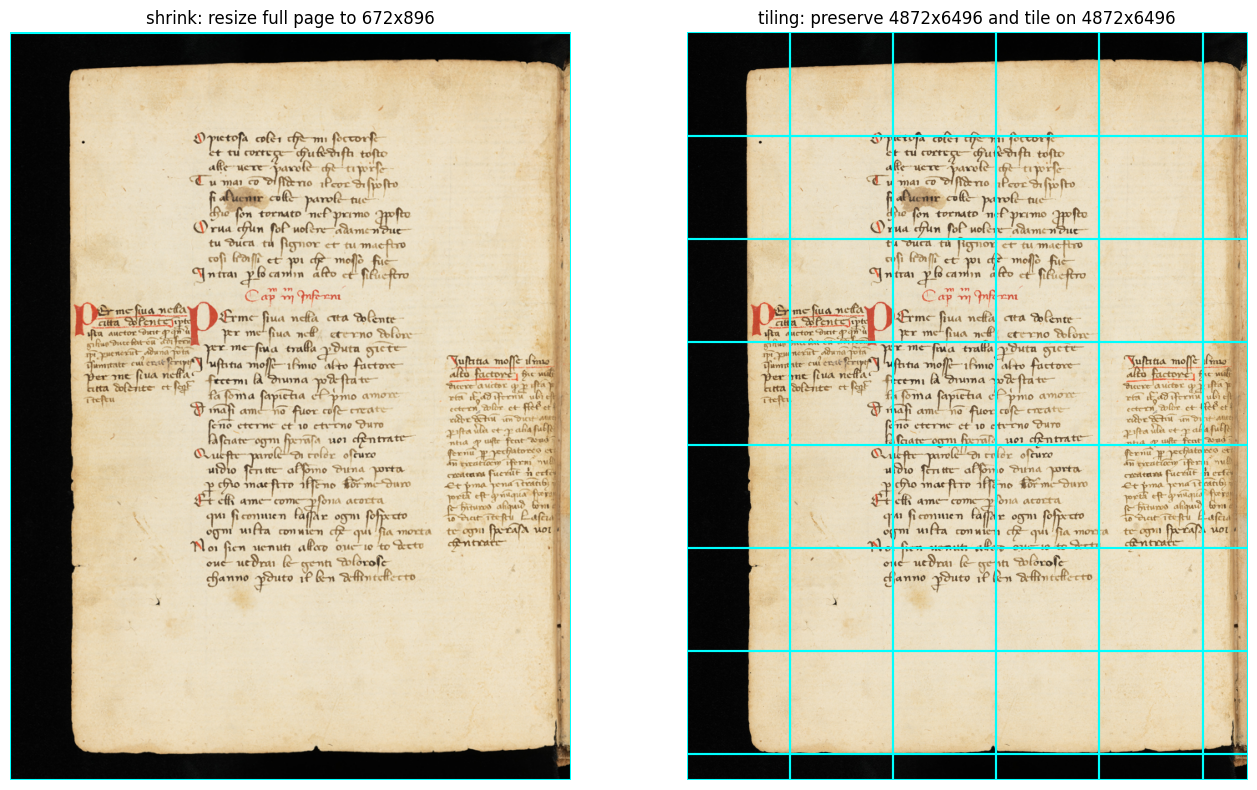

In [37]:
LONG_SIDE = 896
TILE_SIZE = 896
assert TILE_SIZE % PATCH_SIZE == 0

pil_img = Image.open(IMG_PATH).convert("RGB")
w0, h0 = pil_img.size

def round_to_patch(value, patch_size):
    return max(patch_size, int(round(value / patch_size)) * patch_size)

def resize_long_side(image, long_side):
    width, height = image.size
    scale = min(1.0, long_side / max(width, height))
    new_w = round_to_patch(width * scale, PATCH_SIZE)
    new_h = round_to_patch(height * scale, PATCH_SIZE)
    return image.resize((new_w, new_h), Image.BICUBIC)

def pad_to_patch_grid(image):
    width, height = image.size
    padded_w = int(np.ceil(width / PATCH_SIZE)) * PATCH_SIZE
    padded_h = int(np.ceil(height / PATCH_SIZE)) * PATCH_SIZE
    padded = Image.new("RGB", (padded_w, padded_h), color=(255, 255, 255))
    padded.paste(image, (0, 0))
    return padded

pil_resized = resize_long_side(pil_img, LONG_SIDE)
resized_w, resized_h = pil_resized.size
padded_img = pad_to_patch_grid(pil_img)
padded_w, padded_h = padded_img.size

mode_specs = {
    "shrink": {
        "input_image": pil_resized,
        "canvas_image": pil_resized,
        "tile_boxes": [(0, 0, resized_w, resized_h)],
        "display_image": pil_resized,
        "description": f"resize full page to {resized_w}x{resized_h}",
    },
    "tiling": {
        "input_image": pil_img,
        "canvas_image": padded_img,
        "tile_boxes": [
            (x0, y0, min(x0 + TILE_SIZE, padded_w), min(y0 + TILE_SIZE, padded_h))
            for y0 in range(0, padded_h, TILE_SIZE)
            for x0 in range(0, padded_w, TILE_SIZE)
        ],
        "display_image": pil_img,
        "description": f"preserve {w0}x{h0} and tile on {padded_w}x{padded_h}",
    },
}

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
to_tensor = transforms.Compose([transforms.ToTensor(), normalize])

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
for ax, (mode_name, spec) in zip(axes, mode_specs.items()):
    ax.imshow(spec["display_image"] if mode_name == "shrink" else pil_img)
    for x0, y0, x1, y1 in spec["tile_boxes"]:
        ax.add_patch(
            plt.Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                edgecolor="cyan",
                facecolor="none",
                lw=1.5,
            )
        )
    ax.set_title(f"{mode_name}: {spec['description']}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [38]:
results = {}

with torch.no_grad():
    for mode_name, spec in mode_specs.items():
        canvas_image = spec["canvas_image"]
        canvas_w, canvas_h = canvas_image.size
        n_patches_h = canvas_h // PATCH_SIZE
        n_patches_w = canvas_w // PATCH_SIZE
        token_map = np.zeros((EMBED_DIM, n_patches_h, n_patches_w), dtype=np.float32)
        tile_cls_tokens = []

        for tile_index, (x0, y0, x1, y1) in enumerate(spec["tile_boxes"], start=1):
            tile_img = canvas_image.crop((x0, y0, x1, y1))
            img_tensor = to_tensor(tile_img).unsqueeze(0).to(device)
            feats = dino.forward_features(img_tensor)

            tile_patch_tokens = feats["x_norm_patchtokens"][0]
            tile_cls_tokens.append(feats["x_norm_clstoken"][0].cpu())

            tile_patches_h = (y1 - y0) // PATCH_SIZE
            tile_patches_w = (x1 - x0) // PATCH_SIZE
            tile_map = tile_patch_tokens.T.reshape(EMBED_DIM, tile_patches_h, tile_patches_w).cpu().numpy()

            patch_y0 = y0 // PATCH_SIZE
            patch_y1 = y1 // PATCH_SIZE
            patch_x0 = x0 // PATCH_SIZE
            patch_x1 = x1 // PATCH_SIZE
            token_map[:, patch_y0:patch_y1, patch_x0:patch_x1] = tile_map

            print(
                f"{mode_name} tile {tile_index:02d}/{len(spec['tile_boxes'])}: "
                f"px=({x0}:{x1}, {y0}:{y1}) -> patches={tile_patches_w}x{tile_patches_h}"
            )

        patch_tokens = torch.from_numpy(token_map.reshape(EMBED_DIM, -1).T.copy())
        cls_tokens = torch.stack(tile_cls_tokens)
        display_w, display_h = spec["display_image"].size

        results[mode_name] = {
            "token_map": token_map,
            "patch_tokens": patch_tokens,
            "cls_tokens": cls_tokens,
            "cls_token": cls_tokens.mean(dim=0),
            "canvas_image": canvas_image,
            "display_image": spec["display_image"],
            "tile_boxes": spec["tile_boxes"],
            "valid_patches_h": display_h // PATCH_SIZE,
            "valid_patches_w": display_w // PATCH_SIZE,
            "canvas_h": canvas_h,
            "canvas_w": canvas_w,
            "description": spec["description"],
        }

        print(f"{mode_name} token_map   : {token_map.shape}")
        print(f"{mode_name} patch_tokens: {tuple(patch_tokens.shape)}")
        print(f"{mode_name} cls_tokens  : {tuple(cls_tokens.shape)}")

shrink tile 01/1: px=(0:672, 0:896) -> patches=48x64
shrink token_map   : (768, 64, 48)
shrink patch_tokens: (3072, 768)
shrink cls_tokens  : (1, 768)
tiling tile 01/48: px=(0:896, 0:896) -> patches=64x64
tiling tile 02/48: px=(896:1792, 0:896) -> patches=64x64
tiling tile 03/48: px=(1792:2688, 0:896) -> patches=64x64
tiling tile 04/48: px=(2688:3584, 0:896) -> patches=64x64
tiling tile 05/48: px=(3584:4480, 0:896) -> patches=64x64
tiling tile 06/48: px=(4480:4872, 0:896) -> patches=28x64
tiling tile 07/48: px=(0:896, 896:1792) -> patches=64x64
tiling tile 08/48: px=(896:1792, 896:1792) -> patches=64x64
tiling tile 09/48: px=(1792:2688, 896:1792) -> patches=64x64
tiling tile 10/48: px=(2688:3584, 896:1792) -> patches=64x64
tiling tile 11/48: px=(3584:4480, 896:1792) -> patches=64x64
tiling tile 12/48: px=(4480:4872, 896:1792) -> patches=28x64
tiling tile 13/48: px=(0:896, 1792:2688) -> patches=64x64
tiling tile 14/48: px=(896:1792, 1792:2688) -> patches=64x64
tiling tile 15/48: px=(179

In [ ]:
# visualize one random tile's patch tokens with PCA and ICA
tile_index = 0
for mode_name, res in results.items():
    tile_patch_tokens = res["patch_tokens"].cpu().numpy()
    pca = PCA(n_components=3)
    ica = FastICA(n_components=3, random_state=0)
    pca_proj = pca.fit_transform(tile_patch_tokens)
    ica_proj = ica.fit_transform(tile_patch_tokens)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(pca_proj[:, 0], pca_proj[:, 1], c=pca_proj[:, 2], cmap="viridis", s=5)
    axes[0].set_title(f"{mode_name} PCA of tile {tile_index+1}")
    axes[0].axis("equal")
    axes[1].scatter(ica_proj[:, 0], ica_proj[:, 1], c=ica_proj[:, 2], cmap="viridis", s=5)
    axes[1].set_title(f"{mode_name} ICA of tile {tile_index+1}")
    axes[1].axis("equal")
    plt.tight_layout()
    plt.show()

shrink explained variance ratio (top 3): [0.189 0.124 0.065]
tiling explained variance ratio (top 3): [0.101 0.094 0.071]


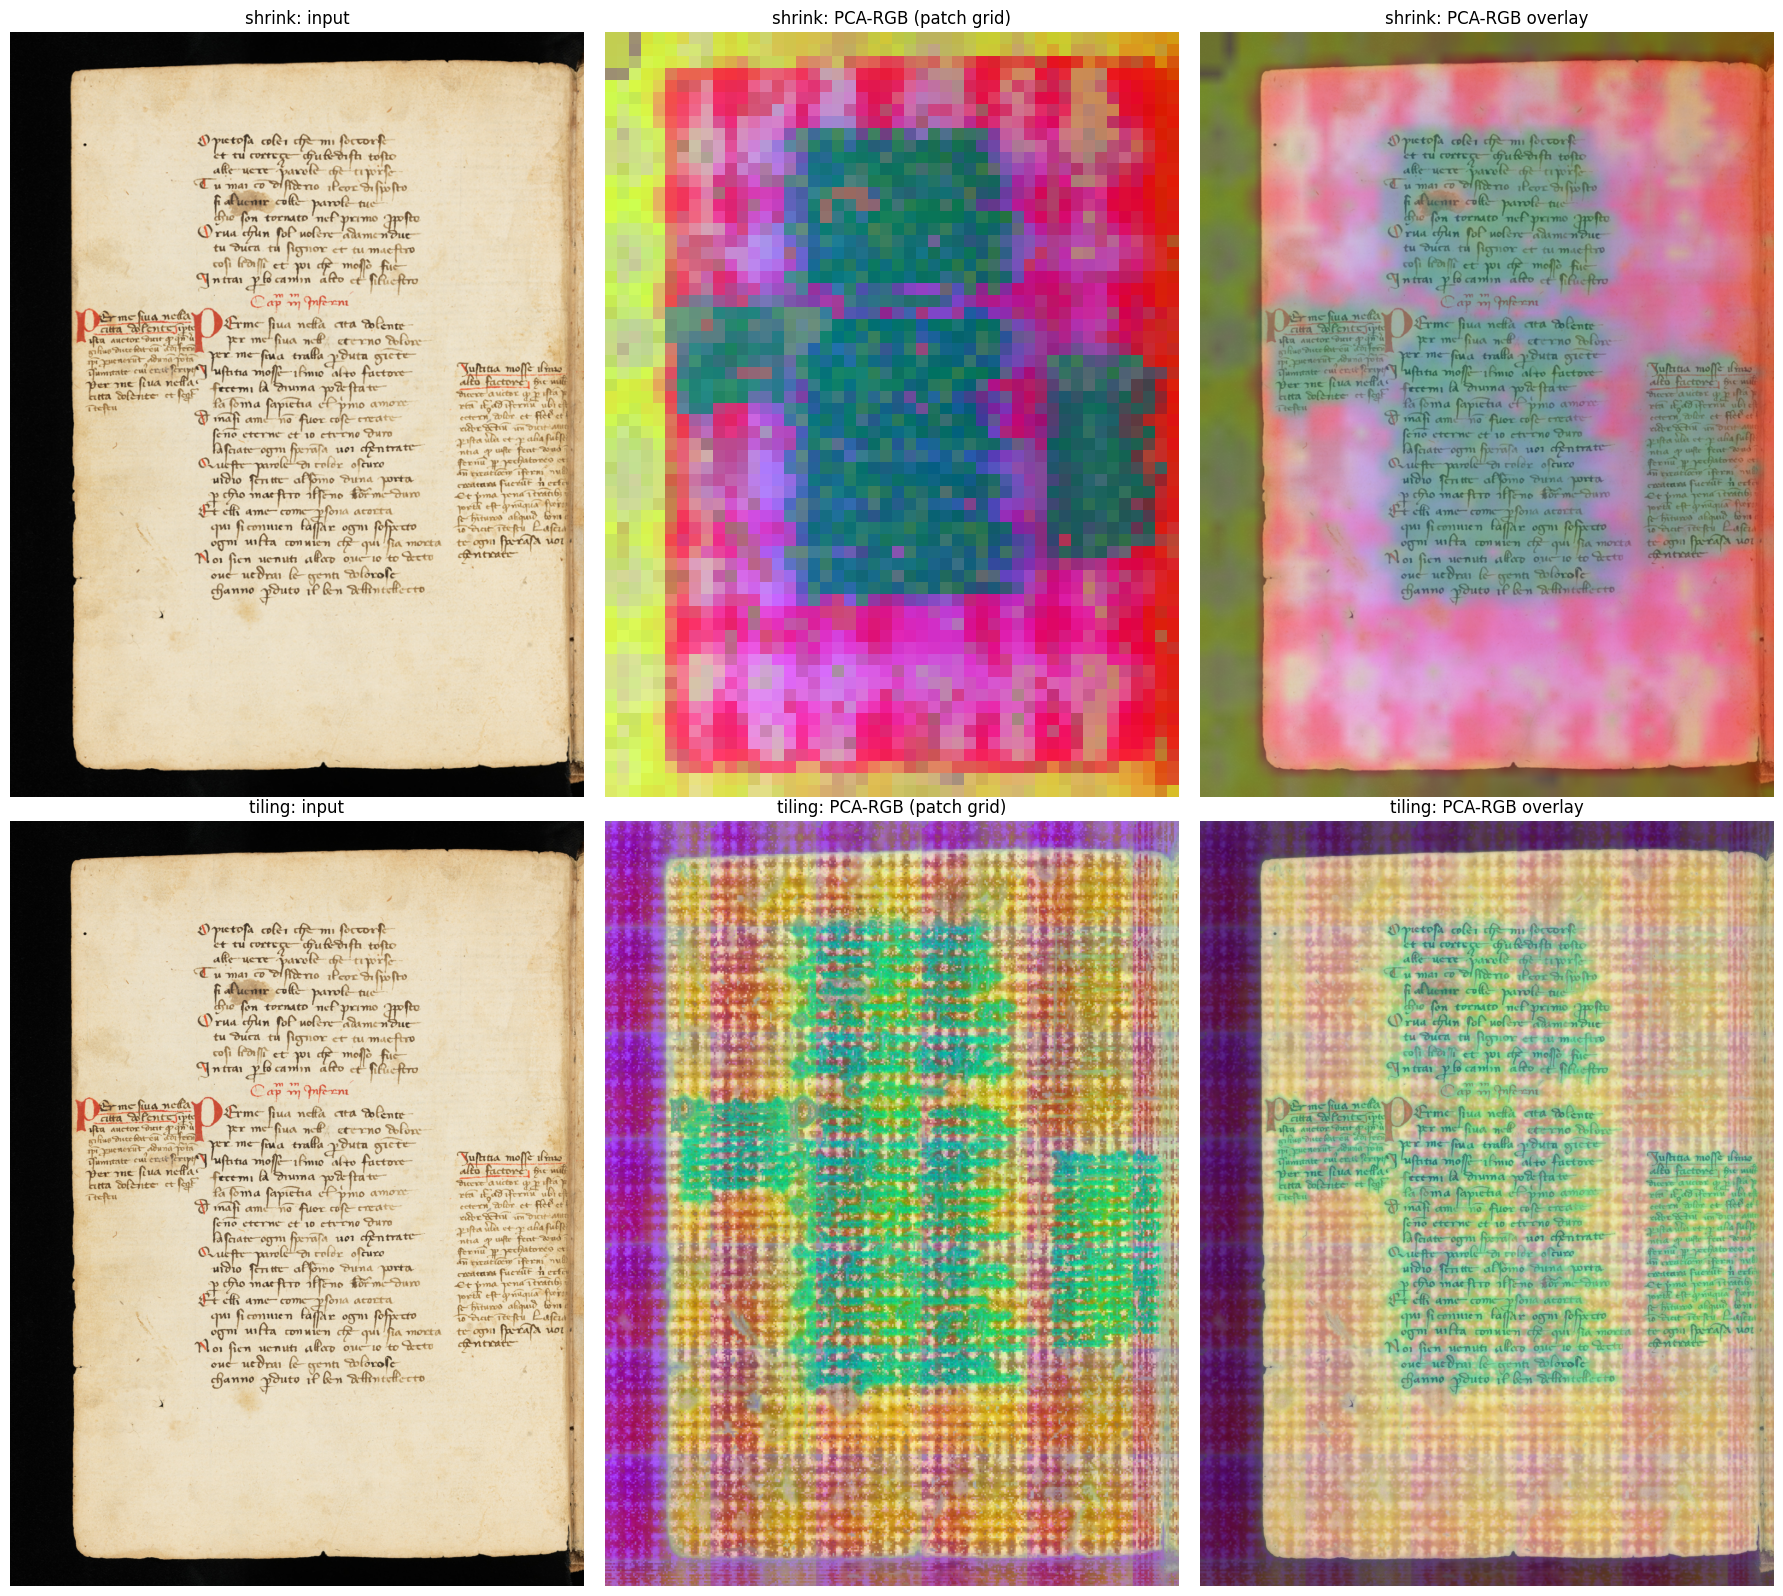

In [39]:
def pca_rgb(feature_map, n_components=3):
    """feature_map: (C, H, W) -> (H, W, 3) in [0, 1]."""
    c, h, w = feature_map.shape
    flat = feature_map.reshape(c, -1).T
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(flat)
    lo = reduced.min(axis=0, keepdims=True)
    hi = reduced.max(axis=0, keepdims=True)
    reduced = (reduced - lo) / np.clip(hi - lo, 1e-6, None)
    return reduced.reshape(h, w, n_components), pca.explained_variance_ratio_

def compute_component_maps(feature_map, n_components=4, method="pca"):
    flat = feature_map.reshape(feature_map.shape[0], -1).T
    if method == "pca":
        reduced = PCA(n_components=n_components).fit_transform(flat)
    elif method == "ica":
        reduced = FastICA(
            n_components=n_components,
            whiten="unit-variance",
            random_state=0,
            max_iter=1000,
        ).fit_transform(flat)
    else:
        raise ValueError(f"Unsupported method: {method}")
    return reduced.T.reshape(n_components, feature_map.shape[1], feature_map.shape[2])

fig, axes = plt.subplots(len(results), 3, figsize=(18, 8 * len(results)))
axes = np.atleast_2d(axes)
for row, (mode_name, result) in enumerate(results.items()):
    rgb_patches, evr = pca_rgb(result["token_map"], n_components=3)
    print(f"{mode_name} explained variance ratio (top 3):", np.round(evr, 3))

    rgb_full = np.array(
        Image.fromarray((rgb_patches * 255).astype(np.uint8)).resize(
            result["display_image"].size, Image.BILINEAR
        )
    ) / 255.0
    rgb_overlay = rgb_full[: result["display_image"].size[1], : result["display_image"].size[0]]

    axes[row, 0].imshow(result["display_image"])
    axes[row, 0].set_title(f"{mode_name}: input")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        rgb_patches[: result["valid_patches_h"], : result["valid_patches_w"]]
    )
    axes[row, 1].set_title(f"{mode_name}: PCA-RGB (patch grid)")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(result["display_image"])
    axes[row, 2].imshow(rgb_overlay, alpha=0.55)
    axes[row, 2].set_title(f"{mode_name}: PCA-RGB overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

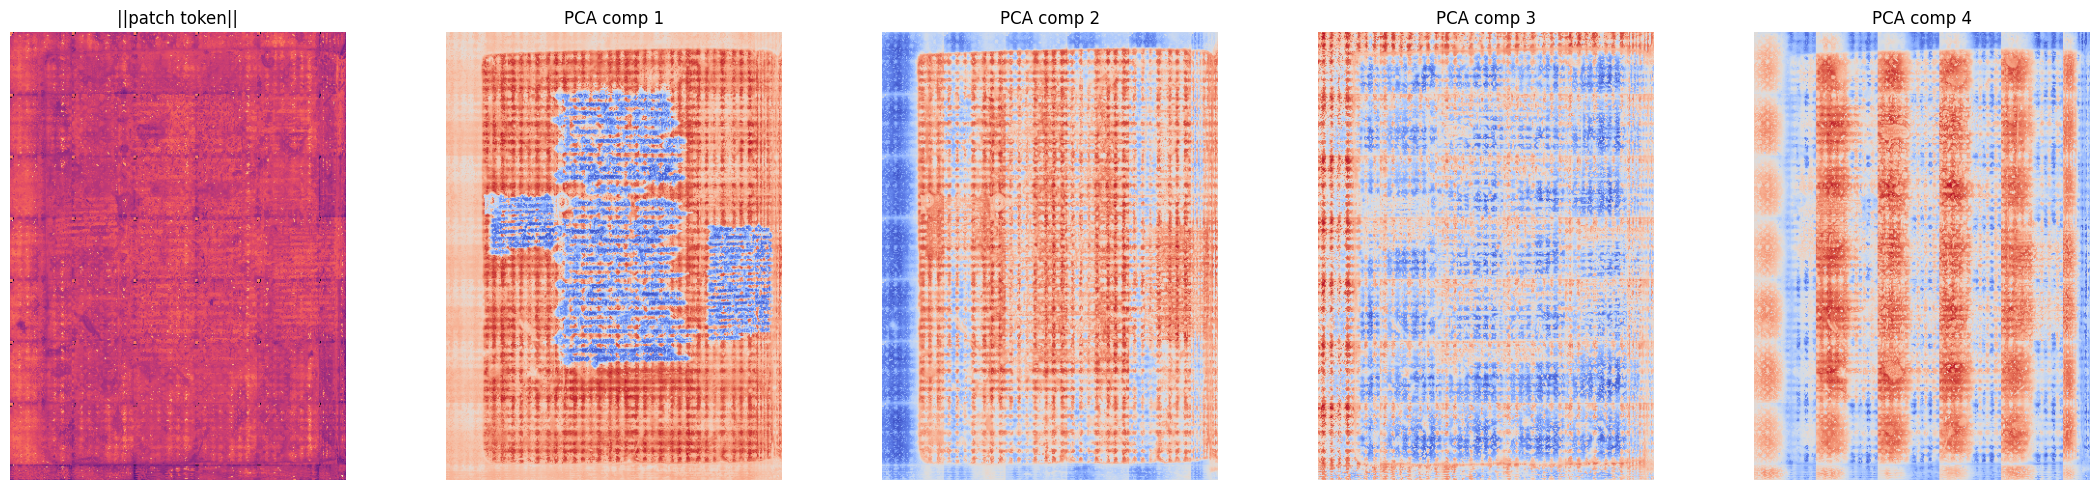

In [40]:
norm_map = np.linalg.norm(token_map, axis=0)

flat = token_map.reshape(EMBED_DIM, -1).T
pca4 = PCA(n_components=4).fit_transform(flat)
pca4 = pca4.T.reshape(4, n_patches_h, n_patches_w)

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
axes[0].imshow(norm_map, cmap="magma")
axes[0].set_title("||patch token||")
axes[0].axis("off")
for i in range(4):
    axes[i + 1].imshow(pca4[i], cmap="coolwarm")
    axes[i + 1].set_title(f"PCA comp {i + 1}")
    axes[i + 1].axis("off")
plt.tight_layout()
plt.show()